In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/iris/Iris.csv
/kaggle/input/iris/database.sqlite


In [2]:
df = pd.read_csv('/kaggle/input/iris/Iris.csv')

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [4]:
df.drop(columns=['Id'], inplace= True)

In [5]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
encoder = LabelEncoder()

In [8]:
df['Species'] = encoder.fit_transform(df['Species'])

In [9]:
df.head()

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [10]:
df = df[df['Species']!=0][['SepalWidthCm','PetalLengthCm','Species']]

In [11]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

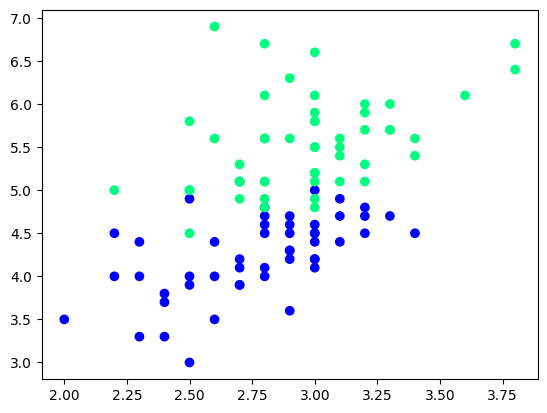

In [13]:
plt.scatter(df['SepalWidthCm'],df['PetalLengthCm'], c = df['Species'] , cmap='winter')

In [14]:
df = df.sample(100)
df_train= df.iloc[:60,:].sample(10)
df_test= df.iloc[60:80,:].sample(5)
df_val= df.iloc[80:,:].sample(5)

In [15]:
df_train

,SepalWidthCm,PetalLengthCm,Species
56,3.3,4.7,1
76,2.8,4.8,1
144,3.3,5.7,2
119,2.2,5.0,2
135,3.0,6.1,2
61,3.0,4.2,1
125,3.2,6.0,2
118,2.6,6.9,2
126,2.8,4.8,2
148,3.4,5.4,2


In [16]:
df_test

,SepalWidthCm,PetalLengthCm,Species
100,3.3,6.0,2
86,3.1,4.7,1
73,2.8,4.7,1
128,2.8,5.6,2
53,2.3,4.0,1


In [17]:
df_val

,SepalWidthCm,PetalLengthCm,Species
59,2.7,3.9,1
57,2.4,3.3,1
62,2.2,4.0,1
80,2.4,3.8,1
51,3.2,4.5,1


In [18]:
x_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

# **Case 1 - Bagging**

In [19]:
df_bag = df_train.sample(8,replace=True)

x = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag


,SepalWidthCm,PetalLengthCm,Species
135,3.0,6.1,2
126,2.8,4.8,2
61,3.0,4.2,1
56,3.3,4.7,1
144,3.3,5.7,2
76,2.8,4.8,1
144,3.3,5.7,2
148,3.4,5.4,2


In [20]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [21]:
dt_bag1 = DecisionTreeClassifier()

In [22]:
def evaluate(clf , x, y):
    clf.fit(x,y)
    plot_tree(clf)
    plt.show()
    plot_decision_regions(x.values , y.values , clf=clf , legend=2 )
    y_pred = clf.predict(x_test)
    print(accuracy_score(y_test, y_pred))

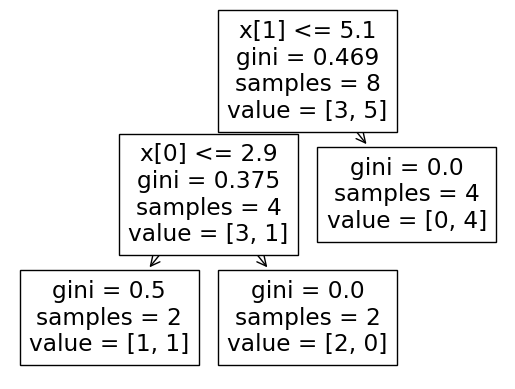

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


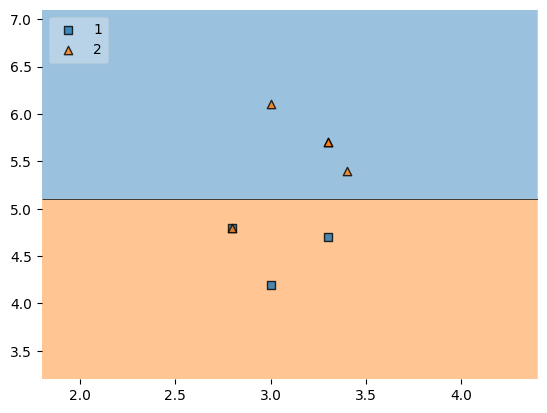

In [23]:
evaluate(dt_bag1, x, y)

In [24]:
df_bag = df_train.sample(8,replace=True)

x = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag


,SepalWidthCm,PetalLengthCm,Species
61,3.0,4.2,1
76,2.8,4.8,1
148,3.4,5.4,2
135,3.0,6.1,2
56,3.3,4.7,1
148,3.4,5.4,2
56,3.3,4.7,1
119,2.2,5.0,2


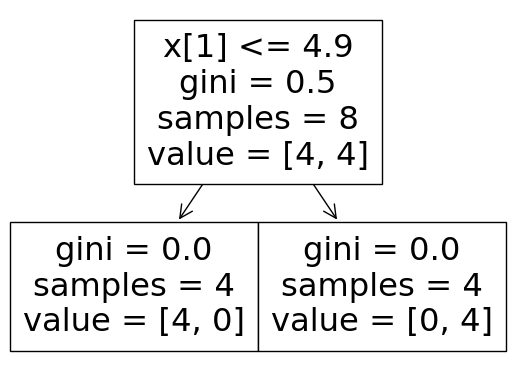

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


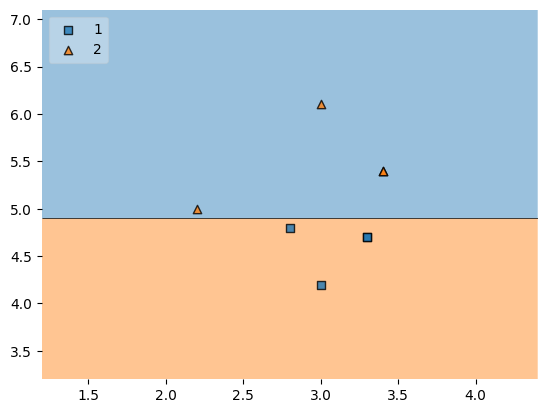

In [25]:
dt_bag2 = DecisionTreeClassifier()
evaluate(dt_bag2, x, y)

In [26]:
df_bag = df_train.sample(8,replace=True)

x = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

df_bag

,SepalWidthCm,PetalLengthCm,Species
76,2.8,4.8,1
56,3.3,4.7,1
118,2.6,6.9,2
144,3.3,5.7,2
61,3.0,4.2,1
119,2.2,5.0,2
76,2.8,4.8,1
126,2.8,4.8,2


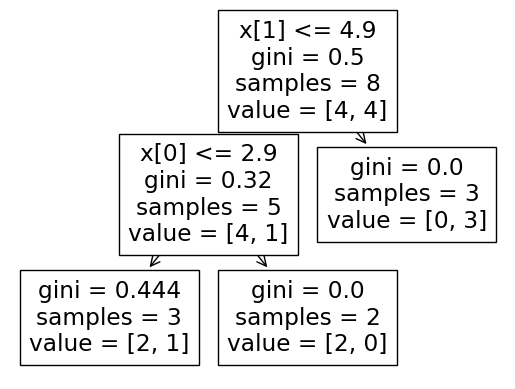

/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


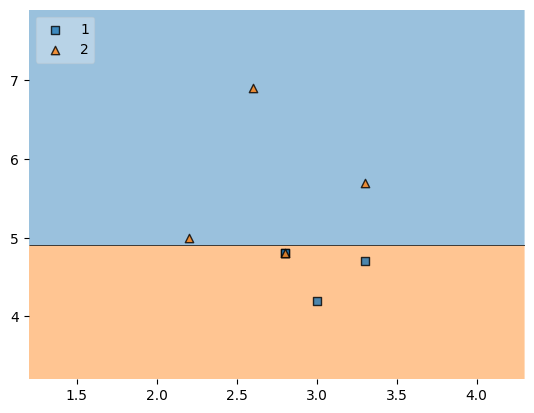

In [27]:
dt_bag3 = DecisionTreeClassifier()
evaluate(dt_bag3, x, y)

# Predict

In [28]:
df_test

,SepalWidthCm,PetalLengthCm,Species
100,3.3,6.0,2
86,3.1,4.7,1
73,2.8,4.7,1
128,2.8,5.6,2
53,2.3,4.0,1


In [29]:
print(" Predictor 1 ", dt_bag1.predict(np.array([3.4	,4.5	]).reshape(1,2)))
print(" Predictor 2 ", dt_bag2.predict(np.array([3.4	,4.5	]).reshape(1,2)))
print(" Predictor 3 ", dt_bag3.predict(np.array([3.4	,4.5	]).reshape(1,2)))

 Predictor 1  [1]
 Predictor 2  [1]
 Predictor 3  [1]


/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


# Pasting - dont repeat


In [30]:
df_train

,SepalWidthCm,PetalLengthCm,Species
56,3.3,4.7,1
76,2.8,4.8,1
144,3.3,5.7,2
119,2.2,5.0,2
135,3.0,6.1,2
61,3.0,4.2,1
125,3.2,6.0,2
118,2.6,6.9,2
126,2.8,4.8,2
148,3.4,5.4,2


In [31]:
df_train.sample(8)

,SepalWidthCm,PetalLengthCm,Species
144,3.3,5.7,2
56,3.3,4.7,1
148,3.4,5.4,2
76,2.8,4.8,1
61,3.0,4.2,1
119,2.2,5.0,2
126,2.8,4.8,2
125,3.2,6.0,2


# Random Subspaces

In [32]:
df1 = pd.read_csv('/kaggle/input/iris/Iris.csv')
df1 = df1.sample(10)

In [33]:
df1

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
121,122,5.6,2.8,4.9,2.0,Iris-virginica
40,41,5.0,3.5,1.3,0.3,Iris-setosa
119,120,6.0,2.2,5.0,1.5,Iris-virginica
9,10,4.9,3.1,1.5,0.1,Iris-setosa
113,114,5.7,2.5,5.0,2.0,Iris-virginica
77,78,6.7,3.0,5.0,1.7,Iris-versicolor
107,108,7.3,2.9,6.3,1.8,Iris-virginica
115,116,6.4,3.2,5.3,2.3,Iris-virginica
28,29,5.2,3.4,1.4,0.2,Iris-setosa
90,91,5.5,2.6,4.4,1.2,Iris-versicolor


In [34]:
df1.sample(2, replace= True , axis=1)

,Id,SepalWidthCm
121,122,2.8
40,41,3.5
119,120,2.2
9,10,3.1
113,114,2.5
77,78,3.0
107,108,2.9
115,116,3.2
28,29,3.4
90,91,2.6


In [35]:
df1.sample(8, replace=True).sample(2,replace=True ,axis=1)

,SepalWidthCm,SepalLengthCm
115,3.2,6.4
119,2.2,6.0
9,3.1,4.9
77,3.0,6.7
107,2.9,7.3
107,2.9,7.3
115,3.2,6.4
115,3.2,6.4
